GEOMETRY:  flat CPW (COMSOL cross-section)
--------------------------------------------------------------------------------------------
  f0 = 60 GHz   lambda0 = 4997 um   gold Rs = 72.07 mOhm/sq  (skin depth 304.2 nm)
  ground metal spans x = 20.990 .. 90.990 um  (W_G = 70.000 um)
  metal occupies y levels [0.193, 1.832]  ->  single flat level
  tee: W1=38.109  W2=25.994  L1=51.387  L2=173.248 um   pitch 200.0 um
  slot reaches 64.10 um of the 70.00 um ground, leaving a 5.90 um rim
--------------------------------------------------------------------------------------------
  section stem + cap open  l =   51.39 um (25.7 %)  slot bands [20.99, 59.10], [59.10, 85.09]
  section cap only         l =  121.86 um (60.9 %)  slot bands [59.10, 85.09]
  section solid ground     l =   26.75 um (13.4 %)  slot bands none


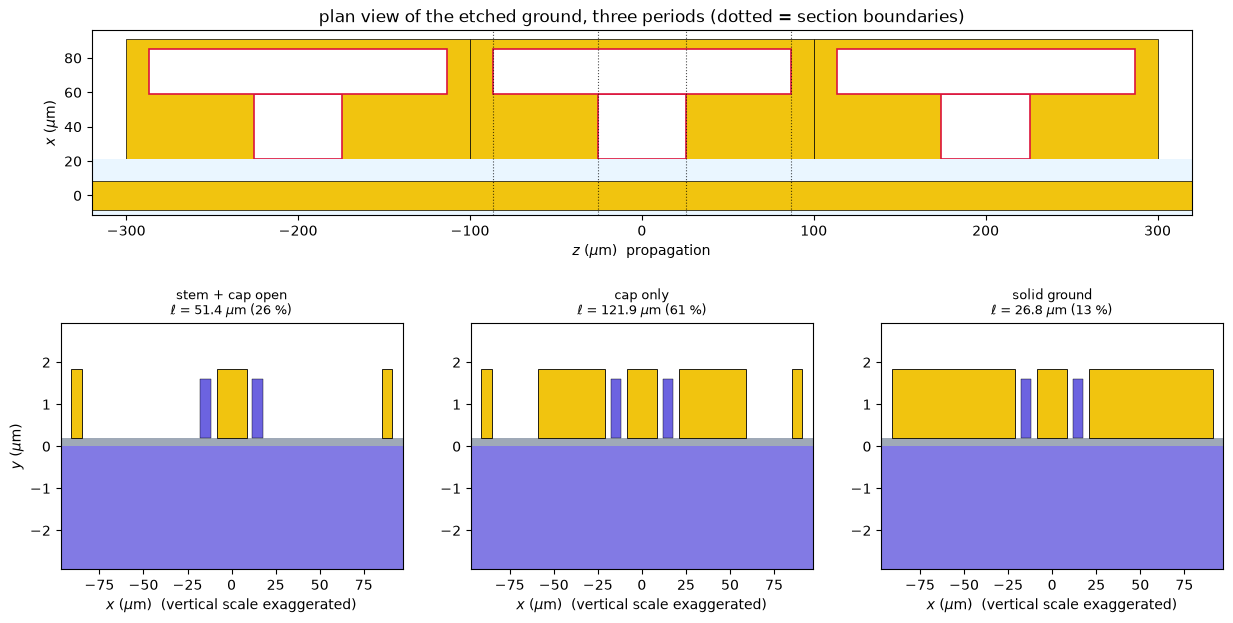

In [1]:
# %% [0] YOUR GEOMETRY -- edit this cell and re-run [0]-[5]
#
# Self-contained.  Nothing here reads a dataset: every number this notebook
# prints is solved from the geometry you type below.  Cell [5] will compare
# against the recorded CST sweep IF it finds the reference file, and skip
# quietly if it does not.
#
# What comes out the other end, for the geometry in this cell:
#     delta C', delta L', delta Z0, delta n_m  and  delta alpha
# for one period of the tee-etched line, against its own unetched reference.
import pathlib
import time
import warnings
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from shapely.affinity import scale as _scale
from shapely.geometry import MultiPolygon, Polygon, box
from shapely.ops import unary_union
from skfem import (Basis, BilinearForm, ElementTriP0, ElementTriP1, Functional,
                   InteriorFacetBasis, LinearForm, MeshTri, asm, condense, solve)
from skfem.helpers import dot, grad
from femwell.mesh import mesh_from_OrderedDict

warnings.filterwarnings("ignore")
C0, EPS0, MU0 = 299792458.0, 8.8541878128e-12, 4.0e-7 * np.pi
DB_PER_NEPER = 20.0 * np.log10(np.e)

# ------------------------------------------------------------------
# frequency and metal
# ------------------------------------------------------------------
F0 = 60.0e9                 # Hz
SIGMA_AU = 4.561e7          # S/m   CST "Gold" Kappa / COMSOL Au node
SKIN_AU = np.sqrt(2.0 / (2 * np.pi * F0 * MU0 * SIGMA_AU))
RS_AU = 1.0 / (SIGMA_AU * SKIN_AU)

# ------------------------------------------------------------------
# materials.  eps_rf = (eps_xx, eps_yy); x is transverse, y is vertical.
# X-cut LN has the extraordinary axis across the gap, hence (28, 44).
# ------------------------------------------------------------------
EPS = {"LN": (28.0, 44.0), "SiO2": (3.9, 3.9), "Si": (11.7, 11.7),
       "air": (1.0, 1.0), "Au": (1.0, 1.0)}   # metal DOFs are pinned; its eps is never used
COL = {"LN": "#8e9aab", "SiO2": "#6c63e0", "Si": "#7f8c8d", "air": "#ffffff",
       "Au": "#f1c40f"}

# ------------------------------------------------------------------
# THE TEE.  Slot bands are measured outwards from the INNERMOST ground metal
# edge, and are cut through the full metal thickness, whatever height that
# metal happens to sit at:
#     stem   x in [x_gi,      x_gi+W1]        over a length L1 of the period
#     cap    x in [x_gi+W1,   x_gi+W1+W2]     over a length L2 of the period
# ------------------------------------------------------------------
# The default below is deliberately the most extreme tee in the recorded CST
# sweep -- it leaves only a 5.9 um ground rim -- so the "this is ohmic only"
# caveat in cell [4] is visible on the very first run.  Replace it with yours.
PITCH = 200.0
TEE = dict(W1=38.109, W2=25.994, L1=51.387, L2=173.248)


# ------------------------------------------------------------------
# THE CROSS-SECTION.  Give the x > 0 half; the ground and the local dielectric
# features are mirrored for you.  Everything is a rectangle
# (material, x_lo, x_hi, y_lo, y_hi), except `poly` entries which take an
# explicit shapely Polygon so sloped ribs stay exact.
#
#   layers  : (material, y_lo, y_hi)             full-width background
#   blocks  : (material, x_lo, x_hi, y_lo, y_hi) local dielectric features
#   signal  : (x_lo, x_hi, y_lo, y_hi)           given in full, straddling x = 0
#   ground  : (x_lo, x_hi, y_lo, y_hi)           ONE ground, x > 0, mirrored
#
# Metal blocks may sit at ANY height and may be stacked or stepped: the solver
# never assumes a flat electrode, it only ever sees a polygon.
# ------------------------------------------------------------------
def flat_cpw(WS=17.040, GAP=12.470, MTX=1.639, WGND=70.0, cap_w=6.0,
             wg_h=0.267, tfln=0.46, wg_top=0.8, theta=60.0, cap_h=1.4,
             box_h=4.7, si_h=550.0, air_h=550.0, lat_pad=200.0):
    """The COMSOL cross-section: one flat electrode level on a thin-film LN
    slab with etched ribs, over buried oxide and a silicon handle."""
    slab_h = tfln - wg_h
    x_sig, x_gi = WS / 2.0, WS / 2.0 + GAP
    x_go = x_gi + WGND
    x_wg = x_sig + GAP / 2.0
    y_el = slab_h + MTX
    base = wg_h / np.tan(np.deg2rad(theta))
    rib = Polygon([(x_wg - (wg_top + 2 * base) / 2, slab_h),
                   (x_wg - wg_top / 2, slab_h + wg_h),
                   (x_wg + wg_top / 2, slab_h + wg_h),
                   (x_wg + (wg_top + 2 * base) / 2, slab_h)])
    return dict(
        layers=[("Si", -box_h - si_h, -box_h), ("SiO2", -box_h, 0.0),
                ("LN", 0.0, slab_h), ("air", slab_h, slab_h + air_h)],
        blocks=[("SiO2", x_wg - cap_w / 2, x_wg + cap_w / 2, slab_h, slab_h + cap_h)],
        poly=[("LN", rib)],
        signal=[(-x_sig, x_sig, slab_h, y_el)],
        ground=[(x_gi, x_go, slab_h, y_el)],
        lat_pad=lat_pad, name="flat CPW (COMSOL cross-section)")


def stepped_cpw(WS=17.0, GAP=12.0, MTX=1.6, WGND=70.0, tongue=4.0, step=2.0,
                tfln=0.46, wg_top=0.8, wg_h=0.267, theta=60.0, box_h=4.7,
                si_h=550.0, air_h=550.0, lat_pad=200.0):
    """TEMPLATE for a multi-level coplanar electrode: each conductor has a low
    inner TONGUE sitting straight on the thin film, a vertical riser, and a
    high outer BODY carried on an oxide pedestal of height `step`.  Fill in
    your own numbers -- the point is the shape, not these values."""
    slab_h = tfln - wg_h
    x_sig, x_gi = WS / 2.0, WS / 2.0 + GAP
    x_go = x_gi + WGND
    x_wg = x_sig + GAP / 2.0
    y_lo, y_hi = slab_h, slab_h + step
    base = wg_h / np.tan(np.deg2rad(theta))
    rib = Polygon([(x_wg - (wg_top + 2 * base) / 2, slab_h),
                   (x_wg - wg_top / 2, slab_h + wg_h),
                   (x_wg + wg_top / 2, slab_h + wg_h),
                   (x_wg + (wg_top + 2 * base) / 2, slab_h)])
    return dict(
        layers=[("Si", -box_h - si_h, -box_h), ("SiO2", -box_h, 0.0),
                ("LN", 0.0, slab_h), ("air", slab_h, slab_h + air_h)],
        # oxide pedestals that carry the raised part of each electrode
        blocks=[("SiO2", x_gi + tongue, x_go, y_lo, y_hi),
                ("SiO2", 0.0, x_sig - tongue, y_lo, y_hi)],
        poly=[("LN", rib)],
        # signal: low tongues on both inner edges, high body in the middle
        signal=[(-x_sig, -x_sig + tongue, y_lo, y_lo + MTX),
                (x_sig - tongue, x_sig, y_lo, y_lo + MTX),
                (-x_sig + tongue, x_sig - tongue, y_hi, y_hi + MTX),
                (-x_sig + tongue, -x_sig + tongue + MTX, y_lo, y_hi + MTX),
                (x_sig - tongue - MTX, x_sig - tongue, y_lo, y_hi + MTX)],
        # ground: low tongue at the gap, riser, high body outwards
        ground=[(x_gi, x_gi + tongue, y_lo, y_lo + MTX),
                (x_gi + tongue, x_gi + tongue + MTX, y_lo, y_hi + MTX),
                (x_gi + tongue, x_go, y_hi, y_hi + MTX)],
        lat_pad=lat_pad, name="stepped CPW (multi-level template)")


# >>> pick one <<<
GEOM = flat_cpw()
# GEOM = stepped_cpw()

# ------------------------------------------------------------------
# mesh controls.  CORNER_RES drives the loss integral: every metal vertex
# carries the r^(-1/3) surface-charge singularity, and R' only converges if
# the corners are resolved.  Check anything you intend to trust at MF = 1.5.
# ------------------------------------------------------------------
MF, CORNER_RES, CORNER_BOX, SKIN_T, SKIN_RES = 2.5, 0.12, 0.25, 0.10, 0.25


def _mirror(g):
    return _scale(g, xfact=-1.0, yfact=1.0, origin=(0, 0))


def metal_polys(geom, slot_bands=()):
    """Signal and ground polygons, with the slot bands cut out of the ground.
    A band removes metal at every height, so a slot that crosses a step eats
    both the tongue and the body."""
    sig = unary_union([box(*_reorder(b)) for b in geom["signal"]])
    gnd = [box(*_reorder(b)) for b in geom["ground"]]
    gnd = unary_union(gnd + [_mirror(g) for g in gnd])
    for lo, hi in slot_bands:
        if hi - lo > 1e-9:
            cut = unary_union([box(lo, -1e5, hi, 1e5), box(-hi, -1e5, -lo, 1e5)])
            gnd = gnd.difference(cut)
    return sig, gnd


def _reorder(b):
    x0, x1, y0, y1 = b
    return (min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1))


def ground_inner_edge(geom):
    return min(min(b[0], b[1]) for b in geom["ground"])


def ground_outer_edge(geom):
    return max(max(b[0], b[1]) for b in geom["ground"])


X_GI, X_GO = ground_inner_edge(GEOM), ground_outer_edge(GEOM)
WGND = X_GO - X_GI


def tee_sections(tee=TEE, p=PITCH, x_gi=None, x_go=None):
    """Split one period into its uniform z-sections.  Returns
    (length, slot_bands, label) with slot_bands in absolute x."""
    x_gi = X_GI if x_gi is None else x_gi
    x_go = X_GO if x_go is None else x_go
    W1, W2 = tee["W1"], tee["W2"]
    L1, L2 = tee["L1"], tee["L2"]
    a, b, c = x_gi, min(x_gi + W1, x_go), min(x_gi + W1 + W2, x_go)
    stem, cap = (a, b), (b, c)
    lo, hi = min(L1, L2), max(L1, L2)
    out = [(lo, [stem, cap], "stem + cap open"),
           (hi - lo, [cap] if L2 >= L1 else [stem],
            "cap only" if L2 >= L1 else "stem only"),
           (p - hi, [], "solid ground")]
    return [(ln, bands, nm) for ln, bands, nm in out if ln > 1e-9]


SECTIONS = tee_sections()

print("=" * 92)
print(f"GEOMETRY:  {GEOM['name']}")
print("-" * 92)
print(f"  f0 = {F0/1e9:.0f} GHz   lambda0 = {C0/F0*1e6:.0f} um   "
      f"gold Rs = {RS_AU*1e3:.2f} mOhm/sq  (skin depth {SKIN_AU*1e9:.1f} nm)")
print(f"  ground metal spans x = {X_GI:.3f} .. {X_GO:.3f} um  (W_G = {WGND:.3f} um)")
_ys = sorted({round(min(b[2], b[3]), 4) for b in GEOM["signal"] + GEOM["ground"]} |
             {round(max(b[2], b[3]), 4) for b in GEOM["signal"] + GEOM["ground"]})
print(f"  metal occupies y levels {_ys}  ->  "
      f"{'MULTI-LEVEL electrode' if len(_ys) > 2 else 'single flat level'}")
print(f"  tee: W1={TEE['W1']:.3f}  W2={TEE['W2']:.3f}  L1={TEE['L1']:.3f}  "
      f"L2={TEE['L2']:.3f} um   pitch {PITCH:.1f} um")
print(f"  slot reaches {TEE['W1']+TEE['W2']:.2f} um of the {WGND:.2f} um ground, "
      f"leaving a {WGND-TEE['W1']-TEE['W2']:.2f} um rim")
print("-" * 92)
for ln, bands, nm in SECTIONS:
    bs = ", ".join(f"[{a:.2f}, {b:.2f}]" for a, b in bands) or "none"
    print(f"  section {nm:<16} l = {ln:7.2f} um ({100*ln/PITCH:4.1f} %)  "
          f"slot bands {bs}")
print("=" * 92)

# ---- preview ---------------------------------------------------------------
fig = plt.figure(figsize=(15.0, 7.0))
gs = fig.add_gridspec(2, len(SECTIONS), height_ratios=[0.75, 1.0], hspace=0.5)

ax = fig.add_subplot(gs[0, :])
for k in (-1, 0, 1):
    z0 = k * PITCH
    ax.add_patch(Rectangle((z0 - PITCH / 2, X_GI), PITCH, WGND,
                           fc=COL["Au"], ec="k", lw=0.5))
    ax.add_patch(Rectangle((z0 - TEE["L1"] / 2, X_GI), TEE["L1"], TEE["W1"],
                           fc="w", ec="crimson", lw=1.2))
    ax.add_patch(Rectangle((z0 - TEE["L2"] / 2, X_GI + TEE["W1"]), TEE["L2"],
                           TEE["W2"], fc="w", ec="crimson", lw=1.2))
_xs = max(max(abs(b[0]), abs(b[1])) for b in GEOM["signal"])
ax.add_patch(Rectangle((-1.6 * PITCH, -X_GI), 3.2 * PITCH, 2 * X_GI,
                       fc="#eaf6ff", ec="none"))
ax.add_patch(Rectangle((-1.6 * PITCH, -_xs), 3.2 * PITCH, 2 * _xs,
                       fc=COL["Au"], ec="k", lw=0.5))
for zb in (TEE["L1"] / 2, TEE["L2"] / 2):
    for s in (-1, 1):
        ax.axvline(s * zb, color="k", ls=":", lw=0.8, alpha=0.7)
ax.set_xlim(-1.6 * PITCH, 1.6 * PITCH); ax.set_ylim(-_xs - 3, X_GO + 5)
ax.set_aspect("equal")
ax.set_xlabel(r"$z$ ($\mu$m)  propagation"); ax.set_ylabel(r"$x$ ($\mu$m)")
ax.set_title("plan view of the etched ground, three periods "
             "(dotted = section boundaries)")

for j, (ln, bands, nm) in enumerate(SECTIONS):
    ax = fig.add_subplot(gs[1, j])
    sig, gnd = metal_polys(GEOM, bands)
    for mat, y0, y1 in GEOM["layers"]:
        ax.add_patch(Rectangle((-X_GO - 12, y0), 2 * (X_GO + 12), y1 - y0,
                               fc=COL[mat], ec="none", alpha=0.85))
    for mat, x0, x1, y0, y1 in GEOM["blocks"]:
        for s in (1, -1):
            ax.add_patch(Rectangle((min(s * x0, s * x1), y0), abs(x1 - x0),
                                   y1 - y0, fc=COL[mat], ec="k", lw=0.3))
    for g in ([sig] if sig.geom_type == "Polygon" else list(sig.geoms)) + \
             ([gnd] if gnd.geom_type == "Polygon" else list(gnd.geoms)):
        ax.fill(*g.exterior.xy, fc=COL["Au"], ec="k", lw=0.6)
    ax.set_xlim(-X_GO - 6, X_GO + 6)
    _yt = max(max(b[2], b[3]) for b in GEOM["signal"] + GEOM["ground"])
    ax.set_ylim(-1.6 * _yt, _yt + 0.6 * _yt)
    ax.set_xlabel(r"$x$ ($\mu$m)  (vertical scale exaggerated)")
    if j == 0:
        ax.set_ylabel(r"$y$ ($\mu$m)")
    ax.set_title(f"{nm}\n$\\ell$ = {ln:.1f} $\\mu$m ({100*ln/PITCH:.0f} %)", fontsize=9)
plt.show()


BACKGROUND WAVES OF THE STACK YOU ENTERED
--------------------------------------------------------------------------------------------
   eps =  1.000   thickness = semi-infinite
   eps = 11.700   thickness =   550.000 um
   eps =  3.900   thickness =     4.700 um
   eps = 36.000   thickness =     0.193 um
   eps =  1.000   thickness = semi-infinite
   TE surface waves : [2.5401]
   TM surface waves : [1.1498]
   slowest background wave available : n = 2.5401
--------------------------------------------------------------------------------------------
   A background wave carries power AWAY from the line when its index
   exceeds the CPW mode index.  Cell [2] computes n_m; the verdict is
   printed there, once n_m is known.
FLOQUET CHECK FOR THE PERIOD
--------------------------------------------------------------------------------------------
   pitch p = 200.0 um,  lambda0 = 4997 um
   m = -1 grating lobe opens at p > lambda0/(n_m + n_bg) = 1113 um  (assuming n_m ~ 1.95)
   Bragg stop

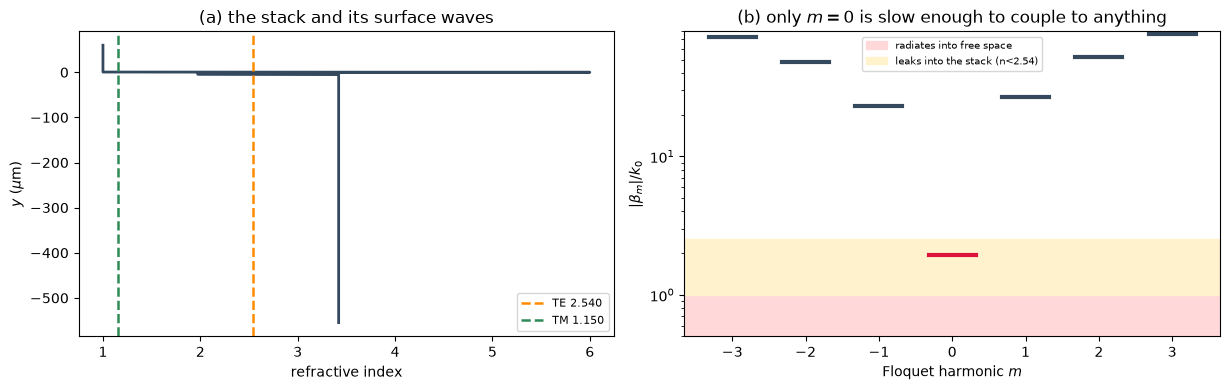

In [2]:
# %% [1] Is the ohmic answer the WHOLE answer for this stack?
#
# Everything cells [2] and [3] compute is ohmic and reactive.  Whether that is
# the whole perturbation depends on one question: can the stack you typed in
# carry a background wave SLOWER than the CPW mode?  If it can, the tee's slot
# is an aperture in the ground shield that couples to it, and a quasi-static
# cell -- which has no radiation channel of any kind -- will be blind to that.
#
# Two separate checks:
#   (i)  the Floquet harmonics of the period (grating lobes / Bragg)
#   (ii) the surface waves of the laterally infinite layer stack, from a 1D
#        transfer matrix.  A guided mode is a pole: no incoming wave below.
from scipy.optimize import brentq

k0 = 2.0 * np.pi * F0 / C0 * 1e-6                       # rad/um


def tmm_stack(geom):
    """(eps, thickness) bottom-up, semi-infinite claddings at both ends.
    The LN tensor is averaged: at 0.2-0.5 um out of a 550 um substrate its
    contribution to a background wave is four orders down, so it cannot matter."""
    lay = sorted(geom["layers"], key=lambda t: t[1])
    inner = [(float(np.mean(EPS[m])), y1 - y0) for m, y0, y1 in lay
             if np.isfinite(y1 - y0) and (y1 - y0) < 1e4]
    # the outermost layer on each side is the cladding, taken semi-infinite
    if inner and abs(inner[-1][0] - 1.0) < 1e-9:
        inner = inner[:-1]
    return [(1.0, np.inf)] + inner + [(1.0, np.inf)]


STACK = tmm_stack(GEOM)


def _det(neff, pol, stack):
    kz = [np.sqrt(complex(e) * k0 ** 2 - (neff * k0) ** 2) for e, _ in stack]
    M = np.eye(2, dtype=complex)
    for i in range(len(stack) - 1):
        e1, e2 = stack[i][0], stack[i + 1][0]
        r = (kz[i] / kz[i + 1]) if pol == "TE" else (kz[i] * e2) / (kz[i + 1] * e1)
        M = M @ (0.5 * np.array([[1 + r, 1 - r], [1 - r, 1 + r]], dtype=complex))
        if i + 1 < len(stack) - 1:
            ph = kz[i + 1] * stack[i + 1][1]
            M = M @ np.array([[np.exp(-1j * ph), 0], [0, np.exp(1j * ph)]])
    return M[0, 0]


def surface_waves(stack, pol, n=5000):
    n_max = np.sqrt(max(e for e, _ in stack))
    if n_max <= 1.0 + 1e-9:
        return []
    ns = np.linspace(1.0005, n_max - 1e-4, n)
    v = np.abs([_det(x, pol, stack) for x in ns])
    out = []
    for i in range(1, n - 1):
        if v[i] < v[i - 1] and v[i] < v[i + 1] and v[i] < 0.1 * v.max():
            lo, hi = ns[i - 1], ns[i + 1]
            f = lambda x: _det(x, pol, stack).real
            try:
                out.append(brentq(f, lo, hi, xtol=1e-11) if f(lo) * f(hi) < 0 else ns[i])
            except Exception:
                out.append(ns[i])
    return out


N_TE, N_TM = surface_waves(STACK, "TE"), surface_waves(STACK, "TM")
N_BG = max(N_TE + N_TM + [1.0])          # slowest background wave available

print("=" * 92)
print("BACKGROUND WAVES OF THE STACK YOU ENTERED")
print("-" * 92)
for e, d in STACK:
    print(f"   eps = {e:6.3f}   thickness = "
          f"{'semi-infinite' if not np.isfinite(d) else f'{d:9.3f} um'}")
print(f"   TE surface waves : {[round(x, 4) for x in N_TE] or 'none'}")
print(f"   TM surface waves : {[round(x, 4) for x in N_TM] or 'none'}")
print(f"   slowest background wave available : n = {N_BG:.4f}")
print("-" * 92)
print("   A background wave carries power AWAY from the line when its index")
print("   exceeds the CPW mode index.  Cell [2] computes n_m; the verdict is")
print("   printed there, once n_m is known.")
print("=" * 92)
print("FLOQUET CHECK FOR THE PERIOD")
print("-" * 92)
_nm_guess = 1.95
print(f"   pitch p = {PITCH:.1f} um,  lambda0 = {C0/F0*1e6:.0f} um")
print(f"   m = -1 grating lobe opens at p > lambda0/(n_m + n_bg) = "
      f"{(C0/F0*1e6)/(_nm_guess + N_BG):.0f} um  (assuming n_m ~ {_nm_guess:.2f})")
print(f"   Bragg stop band opens at p > lambda0/(2 n_m) = "
      f"{(C0/F0*1e6)/(2*_nm_guess):.0f} um")
print(f"   beta_0 p ~ {k0*_nm_guess*PITCH:.3f} rad,  p/lambda_g ~ "
      f"{PITCH*_nm_guess/(C0/F0*1e6):.4f}")
if PITCH < (C0 / F0 * 1e6) / (_nm_guess + N_BG):
    print("   -> every harmonic but m = 0 is evanescent, and the period is deeply")
    print("      sub-wavelength: the line HOMOGENISES, which is what cell [2] uses.")
else:
    print("   -> WARNING: a grating lobe is open at this pitch.  The homogenised")
    print("      cell in [2] is not valid here; you need a full-wave treatment.")
print("=" * 92)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.0))
ax = axes[0]
yy = np.linspace(min(y for _, y, _ in GEOM["layers"]),
                 min(max(y for _, _, y in GEOM["layers"]), 60.0), 1200)
ee = np.ones_like(yy)
for m, y0, y1 in GEOM["layers"]:
    ee[(yy >= y0) & (yy < y1)] = float(np.mean(EPS[m]))
ax.plot(np.sqrt(ee), yy, lw=2, color="#34495e")
for n_, lab, c in [(x, f"TE {x:.3f}", "darkorange") for x in N_TE] + \
                  [(x, f"TM {x:.3f}", "seagreen") for x in N_TM]:
    ax.axvline(n_, color=c, lw=1.8, ls="--", label=lab)
ax.set_xlabel("refractive index"); ax.set_ylabel(r"$y$ ($\mu$m)")
ax.set_title("(a) the stack and its surface waves"); ax.legend(fontsize=8)

ax = axes[1]
ms = np.arange(-3, 4)
for m in ms:
    bm = abs(_nm_guess + 2 * np.pi * m / (k0 * PITCH))
    ax.plot([m - 0.32, m + 0.32], [bm] * 2, lw=3,
            color="crimson" if m == 0 else "#34495e")
ax.axhspan(0, 1.0, color="#ffd9d9", label="radiates into free space")
if N_BG > 1.0:
    ax.axhspan(1.0, N_BG, color="#fff2cc", label=f"leaks into the stack (n<{N_BG:.2f})")
ax.set_yscale("log"); ax.set_ylim(0.5, 80)
ax.set_xlabel("Floquet harmonic $m$"); ax.set_ylabel(r"$|\beta_m|/k_0$")
ax.set_title("(b) only $m=0$ is slow enough to couple to anything")
ax.legend(fontsize=7.5, loc="upper center")
plt.tight_layout(); plt.show()


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


...

Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


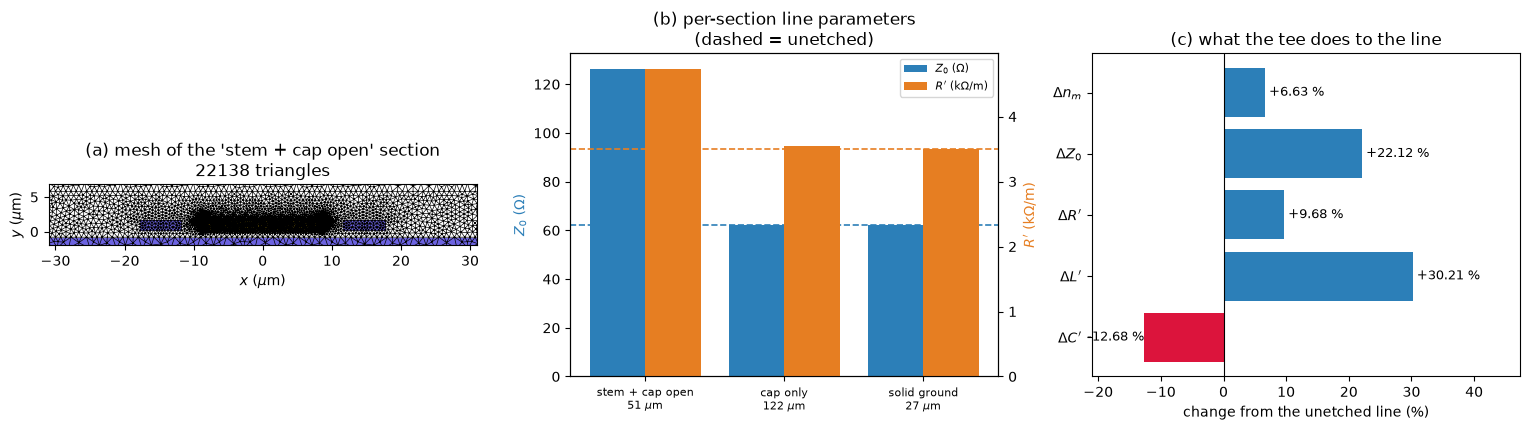

In [3]:
# %% [2] The periodic unit cell -- C', L', R' of the etched line and its reference
#
# beta_0 p is well under 1 rad (cell [1]), so the period homogenises and the
# etched line is equivalent to a uniform line with
#     C' = (1/p) sum_i l_i C_i      charges add in parallel along z
#     L' = (1/p) sum_i l_i L_i      fluxes add in series along z
#     R' = (1/p) sum_i l_i R_i      dissipations add in series along z
# Each section is solved as a 2D quasi-static problem on its own mesh:
#     C      anisotropic Laplace, V = 1 on the signal, 0 on every ground
#     C_air  the same with every eps set to 1;  L = 1/(c^2 C_air)
#     R'     Rs * contour integral of |E_air . n|^2 / (C_air/eps0)^2, which is
#            Wheeler's incremental-inductance rule written as a contour integral
# Nothing in this assumes a flat electrode: it only ever sees polygons.
def material_at(x, y, geom=None):
    """Material at a point: local blocks first, then explicit polygons, then
    the background layers."""
    geom = GEOM if geom is None else geom
    for mat, x0, x1, y0, y1 in geom["blocks"]:
        for s in (1, -1):
            a, b = sorted((s * x0, s * x1))
            if a - 1e-9 <= x <= b + 1e-9 and min(y0, y1) - 1e-9 <= y <= max(y0, y1) + 1e-9:
                return mat
    for mat, poly in geom.get("poly", []):
        for g in (poly, _mirror(poly)):
            if g.buffer(1e-9).contains(Polygon([(x, y), (x + 1e-9, y),
                                                (x, y + 1e-9)]).centroid):
                return mat
    for mat, y0, y1 in geom["layers"]:
        if y0 - 1e-9 <= y <= y1 + 1e-9:
            return mat
    return "air"


def _clean(g, min_area=2.0e-4):
    if g.is_empty or g.area < min_area:
        return None
    if not g.interiors and g.length > 0 and 4.0 * g.area / g.length < 8.0e-3:
        return None
    return g


def _geomify(g):
    """Sanitised Polygon / MultiPolygon.  Pieces are never handed over one by
    one: femwell fragments a MultiPolygon itself, and splitting it into an
    entry per piece makes its boolean pass hand gmsh empty shapes."""
    if g.is_empty:
        return None
    try:
        g = g.buffer(0)
    except Exception:
        pass
    parts = list(g.geoms) if hasattr(g, "geoms") else [g]
    keep = [c for c in (_clean(x) for x in parts
                        if getattr(x, "geom_type", "") == "Polygon") if c is not None]
    if not keep:
        return None
    return keep[0] if len(keep) == 1 else MultiPolygon(keep)


def build_mesh(geom, slot_bands=(), mf=MF, corner_res=CORNER_RES,
               corner_box=CORNER_BOX, skin_t=SKIN_T, skin_res=SKIN_RES,
               min_pitch=None):
    sig, gnd = metal_polys(geom, slot_bands)
    metal = unary_union([sig, gnd])
    mp = metal.bounds
    y_lo = min(y0 for _, y0, _ in geom["layers"])
    y_hi = max(y1 for _, _, y1 in geom["layers"])
    x_dom = ground_outer_edge(geom) + geom["lat_pad"]

    # clamp the collars so they cannot weld across a narrow slot or strip
    verts = [v for g in (list(metal.geoms) if hasattr(metal, "geoms") else [metal])
             for v in g.exterior.coords]
    xs = np.sort(np.unique(np.round([v[0] for v in verts], 6)))
    if min_pitch is None:
        min_pitch = float(np.min(np.diff(xs))) if xs.size > 1 else 10.0
    skin_t = min(skin_t, 0.30 * min_pitch)
    corner_box = min(corner_box, 0.30 * min_pitch)

    corner_ring = unary_union([box(vx - corner_box, vy - corner_box,
                                   vx + corner_box, vy + corner_box)
                               for vx, vy in verts]).difference(metal)
    skin_ring = metal.buffer(skin_t, join_style=2).difference(metal).difference(corner_ring)
    fine = unary_union([metal, corner_ring, skin_ring])

    feats = []
    for mat, x0, x1, y0, y1 in geom["blocks"]:
        b = box(*_reorder((x0, x1, y0, y1)))
        feats += [(mat, b), (mat, _mirror(b))]
    for mat, poly in geom.get("poly", []):
        feats += [(mat, poly), (mat, _mirror(poly))]

    x_go = ground_outer_edge(geom)
    collar = box(-x_go - 2.0, mp[1] - 1.0, x_go + 2.0, mp[3] + 4.0)
    near = box(-x_go - 15.0, mp[1] - 8.0, x_go + 15.0, mp[3] + 15.0)

    polys, r2m, res, dist, refine = OrderedDict(), {}, {}, {}, set()

    def put(name, g, material, resolution, distance, is_refine=False):
        g = _geomify(g)
        if g is None:
            return
        polys[name] = g; r2m[name] = material
        res[name] = resolution; dist[name] = distance
        if is_refine:
            refine.add(name)

    put("corner_ring", corner_ring, "air", corner_res, 0.6, True)
    put("skin_ring", skin_ring, "air", skin_res, 1.0, True)
    used = fine
    for i, (mat, g) in enumerate(feats):
        gg = g.difference(used)
        put(f"feat{i}", gg, mat, 0.20 * mf, 1.0)
        used = unary_union([used, g])
    put("met_sig", sig, "Au", 0.80 * mf, 3.0)
    put("met_gnd", gnd, "Au", 0.80 * mf, 3.0)
    put("collar", collar.difference(used), "air", 0.30 * mf, 3.0, True)
    used = unary_union([used, collar])

    for j, (mat, ly0, ly1) in enumerate(sorted(geom["layers"], key=lambda t: t[1])):
        strip = box(-x_dom, ly0, x_dom, min(ly1, y_hi))
        th = max(ly1 - ly0, 1e-3)
        r_near = float(np.clip(th / 3.0, 0.15, 3.0)) * mf
        r_far = float(np.clip(th / 3.0, 2.0, 30.0)) * mf
        put(f"L{j}n", strip.intersection(near).difference(used), mat, r_near, 4.0)
        put(f"L{j}f", strip.difference(near).difference(used), mat, r_far, 15.0)
        used = unary_union([used, strip])

    resolutions = {k: {"resolution": res[k], "distance": dist[k]} for k in polys}
    raw = mesh_from_OrderedDict(polys, resolutions=resolutions,
                                default_resolution_min=0.4 * min(corner_res, skin_res),
                                default_resolution_max=35.0)
    mesh = MeshTri(raw.points[:, :2].T, raw.cells_dict["triangle"].T)
    sub = raw.cell_data_dict["gmsh:physical"]["triangle"]
    n2i = {n: (d[0] if hasattr(d, "__getitem__") else d) for n, d in raw.field_data.items()}
    region = np.empty(mesh.nelements, dtype=object)
    for rn, sid in n2i.items():
        bn = rn.split("___")[0]
        if bn in polys:
            region[sub == sid] = bn
    region = region.astype(str)
    mat = np.array([r2m[r] for r in region], dtype=object)
    # refinement collars are a meshing device, not a material: give every one
    # of their elements the material its own centroid actually sits in
    isref = np.isin(region, list(refine))
    if isref.any():
        xc = mesh.p[0, mesh.t].mean(axis=0); yc = mesh.p[1, mesh.t].mean(axis=0)
        for e in np.where(isref)[0]:
            mat[e] = material_at(xc[e], yc[e], geom)
    return dict(mesh=mesh, region=region, mat=mat,
                is_metal=np.isin(region, ("met_sig", "met_gnd")),
                is_sig=region == "met_sig", min_pitch=min_pitch)


@BilinearForm
def _lap(u, v, w):
    return w.ex * grad(u)[0] * grad(v)[0] + w.ey * grad(u)[1] * grad(v)[1]


@Functional
def _dvdn2(w):
    return (w.gu.grad[0] * w.nx + w.gu.grad[1] * w.ny) ** 2


def extract2d(g):
    mesh, mat = g["mesh"], g["mat"]
    is_metal, is_sig = g["is_metal"], g["is_sig"]
    basis = Basis(mesh, ElementTriP1())
    bp0 = basis.with_element(ElementTriP0())
    ex = np.array([EPS[m][0] for m in mat]); ey = np.array([EPS[m][1] for m in mat])
    one = np.ones(mesh.nelements)
    dofs_sig = np.unique(basis.element_dofs[:, np.where(is_sig)[0]])
    dofs_D = np.unique(basis.element_dofs[:, np.where(is_metal)[0]])

    def run(a, b):
        K = asm(_lap, basis, ex=bp0.interpolate(a), ey=bp0.interpolate(b))
        uD = np.zeros(basis.N); uD[dofs_sig] = 1.0
        Kc, fc, uc, I = condense(K, np.zeros(basis.N), x=uD, D=dofs_D)
        u = uc.copy(); u[I] = solve(Kc, fc)
        return u, EPS0 * float((K @ u)[dofs_sig].sum())

    _, C_eps = run(ex, ey)
    V_air, C_air = run(one, one)
    f2t = mesh.f2t
    on = (f2t[1] >= 0) & (is_metal[f2t[0]] ^ is_metal[f2t[1]])
    tot = 0.0
    for side in (0, 1):
        oth = 1 - side
        fac = np.where(on & is_metal[f2t[oth]] & ~is_metal[f2t[side]])[0]
        if fac.size == 0:
            continue
        p = mesh.p[:, mesh.facets[:, fac]]
        tan = p[:, 1, :] - p[:, 0, :]
        nrm = np.vstack([tan[1], -tan[0]]); nrm /= np.linalg.norm(nrm, axis=0)
        mid = p.mean(axis=1)
        cen = mesh.p[:, mesh.t[:, f2t[oth][fac]]].mean(axis=1)
        nrm *= np.sign(((mid - cen) * nrm).sum(axis=0))
        fb = InteriorFacetBasis(mesh, ElementTriP1(), facets=fac, side=side)
        tot += _dvdn2.assemble(fb, gu=fb.interpolate(V_air),
                               nx=nrm[0][:, None], ny=nrm[1][:, None])
    S = C_air / EPS0
    return dict(C=C_eps, C_air=C_air, L=1.0 / (C0 ** 2 * C_air),
                Rp=RS_AU * 1e6 * tot / S ** 2, ntri=mesh.nelements)


def foms(C, L, Rp):
    Z0 = np.sqrt(L / C)
    return dict(C=C, L=L, Rp=Rp, Z0=Z0, n_m=C0 * np.sqrt(L * C),
                alpha=DB_PER_NEPER * (Rp / (2.0 * Z0)) / 100.0)


def bloch(sections, p=PITCH):
    """Exact ABCD cascade of the uniform sections, no homogenisation assumed --
    the check that averaging the period was allowed."""
    M = np.eye(2, dtype=complex)
    for ln, r in sections:
        f = foms(r["C"], r["L"], r["Rp"])
        g = f["Rp"] / (2 * f["Z0"]) + 1j * 2 * np.pi * F0 * f["n_m"] / C0
        gl = g * ln * 1e-6
        M = M @ np.array([[np.cosh(gl), f["Z0"] * np.sinh(gl)],
                          [np.sinh(gl) / f["Z0"], np.cosh(gl)]])
    gB = np.arccosh((M[0, 0] + M[1, 1]) / 2.0) / (p * 1e-6)
    return dict(alpha=gB.real * DB_PER_NEPER / 100.0,
                n_m=gB.imag * C0 / (2 * np.pi * F0),
                Z0=float(np.real(np.sqrt(M[0, 1] / M[1, 0]))))


t0 = time.time()
# one shared collar clamp so the refinement is identical on both sides of the
# subtraction and every mesh-driven bias cancels in the difference
_mp = min(build_mesh(GEOM, b)["min_pitch"] for _, b, _ in SECTIONS)
PER, acc = [], dict(C=0.0, L=0.0, Rp=0.0)
for ln, bands, nm in SECTIONS:
    r = extract2d(build_mesh(GEOM, bands, min_pitch=_mp))
    PER.append((ln, bands, nm, r))
    for k in acc:
        acc[k] += ln * r[k]
ETCHED = foms(*[acc[k] / PITCH for k in ("C", "L", "Rp")])
UNETCHED = foms(**{k: v for k, v in
                   extract2d(build_mesh(GEOM, (), min_pitch=_mp)).items()
                   if k in ("C", "L", "Rp")})
BL = bloch([(ln, r) for ln, _, _, r in PER])
T_CELL = time.time() - t0

D = {k: ETCHED[k] - UNETCHED[k] for k in ("C", "L", "Rp", "Z0", "n_m", "alpha")}

print("=" * 96)
print("PERIODIC UNIT CELL")
print("-" * 96)
print(f"{'section':<18} {'l (um)':>8} {'C (pF/m)':>10} {'L (nH/m)':>10} "
      f"{'R (kOhm/m)':>11} {'Z0':>8} {'n_m':>8} {'a (dB/cm)':>10} {'tris':>8}")
for ln, _, nm, r in PER:
    f = foms(r["C"], r["L"], r["Rp"])
    print(f"{nm:<18} {ln:>8.2f} {r['C']*1e12:>10.3f} {r['L']*1e9:>10.3f} "
          f"{r['Rp']/1e3:>11.3f} {f['Z0']:>8.2f} {f['n_m']:>8.4f} "
          f"{f['alpha']:>10.4f} {r['ntri']:>8}")
print("-" * 96)
for lab, f in (("unetched reference", UNETCHED), ("etched (homogenised)", ETCHED)):
    print(f"{lab:<22} C = {f['C']*1e12:8.3f} pF/m   L = {f['L']*1e9:8.3f} nH/m   "
          f"R' = {f['Rp']/1e3:7.3f} kOhm/m   Z0 = {f['Z0']:7.2f}   "
          f"n_m = {f['n_m']:.4f}   alpha = {f['alpha']:.4f} dB/cm")
print(f"{'exact ABCD cascade':<22} "
      f"{'':38}{'':22}Z0 = {BL['Z0']:7.2f}   n_m = {BL['n_m']:.4f}   "
      f"alpha = {BL['alpha']:.4f} dB/cm")
print(f"   homogenisation error on alpha: "
      f"{100*(ETCHED['alpha']/BL['alpha']-1):+.2f} %   "
      f"(if this is large, the pitch is not sub-wavelength enough)")
print("-" * 96)
print(f"  delta C'   = {D['C']*1e12:+10.4f} pF/m    ({100*D['C']/UNETCHED['C']:+7.2f} %)")
print(f"  delta L'   = {D['L']*1e9:+10.4f} nH/m    ({100*D['L']/UNETCHED['L']:+7.2f} %)")
print(f"  delta R'   = {D['Rp']/1e3:+10.4f} kOhm/m ({100*D['Rp']/UNETCHED['Rp']:+7.2f} %)")
print(f"  delta Z0   = {D['Z0']:+10.4f} ohm     ({100*D['Z0']/UNETCHED['Z0']:+7.2f} %)")
print(f"  delta n_m  = {D['n_m']:+10.5f}         ({100*D['n_m']/UNETCHED['n_m']:+7.2f} %)")
print(f"  delta a    = {D['alpha']:+10.4f} dB/cm   <- cross-section channel only;")
print( "                                        cell [3] adds the current detour")
print("-" * 96)
_open = N_BG > UNETCHED["n_m"]
print(f"  CHANNEL CHECK (cell [1] + n_m just computed):")
print(f"     n_m = {UNETCHED['n_m']:.4f}   slowest background wave n = {N_BG:.4f}")
if _open:
    print(f"     -> n_bg > n_m: the leakage channel is OPEN.  A slot cut in the ground")
    print(f"        is an aperture into it, and NOTHING in this notebook models that.")
    print(f"        The delta alpha below is the OHMIC part only -- a lower bound.")
else:
    print(f"     -> n_bg < n_m: no background wave can carry power away.  The ohmic")
    print(f"        and reactive channels below are the whole perturbation.")
print(f"\n  {len(SECTIONS)+1} cross-sections solved in {T_CELL:.1f} s")
print("=" * 96)

# ---- figure ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.4))
g_show = build_mesh(GEOM, SECTIONS[0][1], min_pitch=_mp)
ax = axes[0]
for nm_ in np.unique(g_show["region"]):
    idx = np.where(g_show["region"] == nm_)[0]
    m2 = MeshTri(g_show["mesh"].p, g_show["mesh"].t[:, idx])
    c = COL["Au"] if nm_.startswith("met_") else COL[g_show["mat"][idx[0]]]
    m2.plot(np.zeros(m2.nelements), ax=ax, shading="flat",
            cmap=plt.matplotlib.colors.ListedColormap([c]))
g_show["mesh"].draw(ax=ax, color="k", lw=0.08)
_yt = max(max(b[2], b[3]) for b in GEOM["signal"] + GEOM["ground"])
ax.set_xlim(-X_GI - 10, X_GI + 10); ax.set_ylim(-2.0, _yt + 5)
ax.set_aspect("equal"); ax.set_xlabel(r"$x$ ($\mu$m)"); ax.set_ylabel(r"$y$ ($\mu$m)")
ax.set_title(f"(a) mesh of the '{SECTIONS[0][2]}' section\n"
             f"{g_show['mesh'].nelements} triangles")

ax = axes[1]
lab = [f"{nm}\n{ln:.0f} $\\mu$m" for ln, _, nm, _ in PER]
xx = np.arange(len(lab))
ax.bar(xx - 0.2, [foms(r["C"], r["L"], r["Rp"])["Z0"] for _, _, _, r in PER],
       0.4, color="#2c7fb8", label=r"$Z_0$ ($\Omega$)")
ax.axhline(UNETCHED["Z0"], color="#2c7fb8", ls="--", lw=1.2)
ax.set_ylabel(r"$Z_0$ ($\Omega$)", color="#2c7fb8")
ax2 = ax.twinx()
ax2.bar(xx + 0.2, [r["Rp"] / 1e3 for _, _, _, r in PER], 0.4, color="#e67e22",
        label=r"$R'$ (k$\Omega$/m)")
ax2.axhline(UNETCHED["Rp"] / 1e3, color="#e67e22", ls="--", lw=1.2)
ax2.set_ylabel(r"$R'$ (k$\Omega$/m)", color="#e67e22")
ax.set_xticks(xx); ax.set_xticklabels(lab, fontsize=8)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8)
ax.set_title("(b) per-section line parameters\n(dashed = unetched)")

ax = axes[2]
keys = [r"$\Delta C'$", r"$\Delta L'$", r"$\Delta R'$", r"$\Delta Z_0$", r"$\Delta n_m$"]
vals = [100 * D[k] / UNETCHED[k] for k in ("C", "L", "Rp", "Z0", "n_m")]
ax.barh(keys, vals, color=["crimson" if v < 0 else "#2c7fb8" for v in vals])
ax.axvline(0, color="k", lw=0.8)
for i, v in enumerate(vals):
    ax.text(v, i, f" {v:+.2f} %", va="center",
            ha="left" if v > 0 else "right", fontsize=9)
ax.set_xlabel("change from the unetched line (%)")
ax.set_xlim(min(vals) * 1.5 - 2, max(vals) * 1.5 + 2)
ax.set_title("(c) what the tee does to the line")
plt.tight_layout(); plt.show()


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


LONGITUDINAL CURRENT DETOUR
------------------------------------------------------------------------------------------------
  ground developed width  70.000 um (projected 70.000 um; risers add 0.000 um)
  solid ground            1.429 squares / half period   -> R' = 514.8 ohm/m
  slotted ground          15.860 squares / half period
  extra                   +14.431 squares   -> delta R' = +5199.8 ohm/m = +5.1998 kOhm/m
  delta alpha (detour)    +3.6395 dB/cm
------------------------------------------------------------------------------------------------
  topological cap: a half period laid along the whole surviving rim is
  17.0 squares.  Anything an ohmic account is asked to buy beyond
  that cannot come from gold at all.


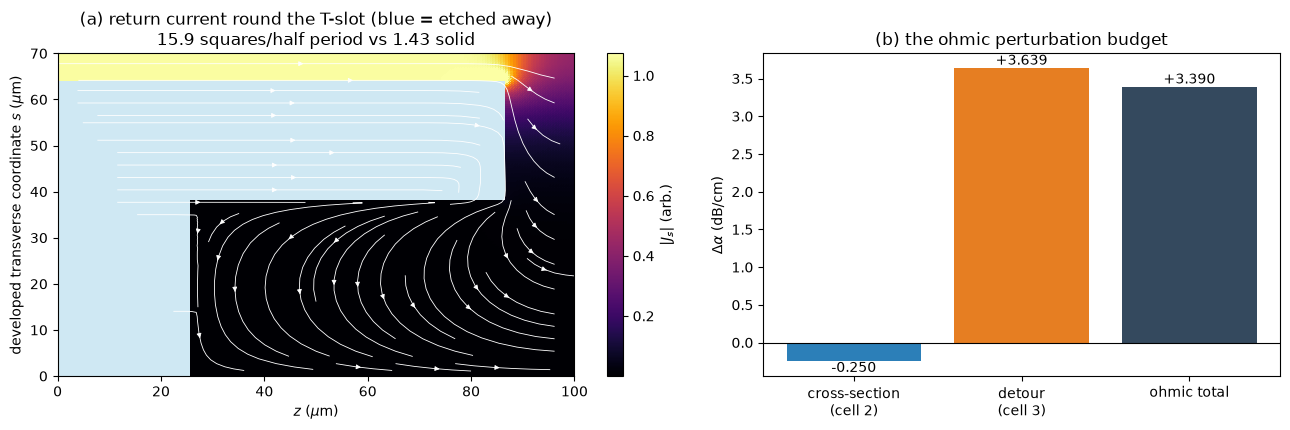

In [4]:
# %% [3] The longitudinal current detour
#
# Cell [2] changed the cross-sections but left every section's current in its
# own 2D modal distribution.  The ohmic channel that leaves out is the detour:
# the slot interrupts the inner ground, so the return current has to cross to
# the surviving outer rim and back, once per period.
#
# Sheet conduction on the ground footprint, with the period built in:
#     phi = -E0 z + psi,   J = (1/Rs)(E0 zhat - grad psi),   div J = 0
# psi is odd about z = 0 (slot centre) and z = p/2 (mid-metal), so psi = 0 on
# both; the slot rim and the two ground edges are insulating.
#
# For a MULTI-LEVEL electrode the footprint is not flat, so the transverse
# coordinate used here is the DEVELOPED arc length s(x) along the ground's top
# surface: crossing a riser of height h costs h of extra path.  Steps are
# present in both the etched and unetched cell, so they largely cancel in the
# difference; what does not cancel is the slot.
#
# Two biases, both deliberately FAVOURABLE to an all-ohmic reading:
#   * the sheet carries Rs per square, i.e. current on ONE face.  Real metal is
#     microns thick against a 304 nm skin depth, so both faces and the sidewalls
#     conduct and the honest detour is nearer Rs/2.
#   * it is converted at the UNETCHED impedance; etching raises Z0, and a given
#     R' then buys more loss.
@BilinearForm
def _sheet(u, v, w):
    return dot(grad(u), grad(v))


@LinearForm
def _drive(v, w):
    return grad(v)[1]


@Functional
def _diss(w):
    return w.gp.grad[0] ** 2 + (1.0 - w.gp.grad[1]) ** 2


def ground_profile(geom, n=4000):
    """Developed arc length s(x) along the top of the unetched ground."""
    _, gnd = metal_polys(geom, ())
    x = np.linspace(X_GI, X_GO, n)
    ytop = np.full(n, np.nan)
    parts = list(gnd.geoms) if hasattr(gnd, "geoms") else [gnd]
    for g in parts:
        x0, y0, x1, y1 = g.bounds
        if x1 < 0:
            continue
        m = (x >= x0 - 1e-9) & (x <= x1 + 1e-9)
        ytop[m] = np.fmax(np.nan_to_num(ytop[m], nan=-1e9), y1)
    ytop = np.where(np.isfinite(ytop) & (ytop > -1e8), ytop, np.nanmin(ytop))
    ds = np.hypot(np.diff(x), np.diff(ytop))
    return x, np.r_[0.0, np.cumsum(ds)]


X_PROF, S_PROF = ground_profile(GEOM)
S_OF_X = lambda xv: np.interp(xv, X_PROF, S_PROF)
W_DEV = float(S_PROF[-1])                      # developed ground width


def _grid(xs, zs):
    X, Z = np.meshgrid(xs, zs, indexing="ij")
    nz = len(zs)
    tri = [[i * nz + j, (i + 1) * nz + j, (i + 1) * nz + j + 1]
           for i in range(len(xs) - 1) for j in range(nz - 1)] + \
          [[i * nz + j, (i + 1) * nz + j + 1, i * nz + j + 1]
           for i in range(len(xs) - 1) for j in range(nz - 1)]
    return np.vstack([X.ravel(), Z.ravel()]), np.array(tri).T


def _axis(lo, hi, breaks, h):
    b = np.unique(np.clip(np.r_[lo, breaks, hi], lo, hi))
    return np.unique(np.concatenate(
        [np.linspace(b[k], b[k + 1], max(2, int(np.ceil((b[k + 1] - b[k]) / h)) + 1))
         for k in range(len(b) - 1)]))


def detour(tee=TEE, p=PITCH, h=0.5, want_field=False):
    """Squares of gold the return current crosses per HALF period, one ground."""
    sa, sb = 0.0, float(S_OF_X(min(X_GI + tee["W1"], X_GO)))
    sc = float(S_OF_X(min(X_GI + tee["W1"] + tee["W2"], X_GO)))
    xs = _axis(0.0, W_DEV, [sb, sc], h)
    zs = _axis(0.0, p / 2, [min(tee["L1"], p) / 2, min(tee["L2"], p) / 2], h)
    pts, t = _grid(xs, zs)
    xc, zc = pts[0, t].mean(axis=0), pts[1, t].mean(axis=0)
    keep = ~(((xc > sa) & (xc < sb) & (zc < tee["L1"] / 2)) |
             ((xc > sb) & (xc < sc) & (zc < tee["L2"] / 2)))
    t = t[:, keep]
    used = np.unique(t)                        # drop nodes stranded in the slot
    remap = np.full(pts.shape[1], -1, dtype=int); remap[used] = np.arange(used.size)
    m = MeshTri(pts[:, used], remap[t])
    basis = Basis(m, ElementTriP1())
    Dd = basis.get_dofs(lambda q: (np.abs(q[1]) < 1e-9) | (np.abs(q[1] - p / 2) < 1e-9))
    psi = solve(*condense(asm(_sheet, basis), asm(_drive, basis), D=Dd))
    Pd = _diss.assemble(basis, gp=basis.interpolate(psi))
    V = p / 2.0
    N = V / (Pd / V) if Pd > 0 else np.nan
    return (float(N), m, psi, basis) if want_field else float(N)


N_SLOT, MD, PSID, BD = detour(want_field=True)
N_FLAT = (PITCH / 2.0) / W_DEV
DN = N_SLOT - N_FLAT
DRP_DETOUR = DN * RS_AU / (PITCH * 1e-6)
DA_DETOUR = DB_PER_NEPER * DRP_DETOUR / (2.0 * UNETCHED["Z0"]) / 100.0
N_CAP = (PITCH / 2.0) / max(W_DEV - S_OF_X(min(X_GI + TEE["W1"] + TEE["W2"], X_GO)), 1e-9)

print("=" * 96)
print("LONGITUDINAL CURRENT DETOUR")
print("-" * 96)
print(f"  ground developed width  {W_DEV:.3f} um "
      f"(projected {X_GO-X_GI:.3f} um; risers add {W_DEV-(X_GO-X_GI):.3f} um)")
print(f"  solid ground            {N_FLAT:.3f} squares / half period"
      f"   -> R' = {N_FLAT*RS_AU/(PITCH*1e-6):.1f} ohm/m")
print(f"  slotted ground          {N_SLOT:.3f} squares / half period")
print(f"  extra                   {DN:+.3f} squares"
      f"   -> delta R' = {DRP_DETOUR:+.1f} ohm/m = {DRP_DETOUR/1e3:+.4f} kOhm/m")
print(f"  delta alpha (detour)    {DA_DETOUR:+.4f} dB/cm")
print("-" * 96)
print(f"  topological cap: a half period laid along the whole surviving rim is")
print(f"  {N_CAP:.1f} squares.  Anything an ohmic account is asked to buy beyond")
print(f"  that cannot come from gold at all.")
print("=" * 96)

# ---- figure ----------------------------------------------------------------
from scipy.interpolate import griddata

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4),
                         gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
cx = MD.p[0, MD.t].mean(axis=0); cz = MD.p[1, MD.t].mean(axis=0)
gu = BD.interpolate(PSID).grad
Jx = -gu[0].mean(axis=1); Jz = 1.0 - gu[1].mean(axis=1)
Jm = np.hypot(Jx, Jz)
ax.set_facecolor("#cfe8f3")
tp = ax.tripcolor(MD.p[1], MD.p[0], MD.t.T, facecolors=Jm, cmap="inferno",
                  shading="flat", vmax=np.quantile(Jm, 0.995))
zi = np.linspace(0, PITCH / 2, 90); xi = np.linspace(0, W_DEV, 70)
ZI, XI = np.meshgrid(zi, xi)
U = griddata((cz, cx), Jz, (ZI, XI)); V = griddata((cz, cx), Jx, (ZI, XI))
ax.streamplot(zi, xi, U, V, color="w", density=0.9, linewidth=0.6, arrowsize=0.7)
ax.set_xlabel(r"$z$ ($\mu$m)")
ax.set_ylabel(r"developed transverse coordinate $s$ ($\mu$m)")
ax.set_title(f"(a) return current round the T-slot (blue = etched away)\n"
             f"{N_SLOT:.1f} squares/half period vs {N_FLAT:.2f} solid")
plt.colorbar(tp, ax=ax, label=r"$|J_s|$ (arb.)")

ax = axes[1]
parts = ["cross-section\n(cell 2)", "detour\n(cell 3)", "ohmic total"]
vals = [D["alpha"], DA_DETOUR, D["alpha"] + DA_DETOUR]
ax.bar(parts, vals, color=["#2c7fb8", "#e67e22", "#34495e"])
ax.axhline(0, color="k", lw=0.8)
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:+.3f}", ha="center",
            va="bottom" if v >= 0 else "top", fontsize=10)
ax.set_ylabel(r"$\Delta\alpha$ (dB/cm)")
ax.set_title("(b) the ohmic perturbation budget")
plt.tight_layout(); plt.show()


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


RESULT  --  flat CPW (COMSOL cross-section),  tee W1=38.109 W2=25.994 L1=51.387 L2=173.248 um, pitch 200.0 um
                                unetched        etched         delta     delta %
------------------------------------------------------------------------------------------------
  C' (pF/m)                     103.3917       90.2785      -13.1132     -12.68 %
  L' (nH/m)                     398.0701      518.3375     +120.2674     +30.21 %
  R' (kOhm/m)                     3.5034        3.8426       +0.3392      +9.68 %
  Z0 (ohm)                       62.0493       75.7729      +13.7236     +22.12 %
  n_m (-)                         1.9233        2.0508       +0.1275      +6.63 %
------------------------------------------------------------------------------------------------
  alpha (dB/cm)                   2.4521        5.8419       +3.3897    +138.24 %
      of which cross-section        -0.2497
      of which detour               +3.6395
HOW TO USE THIS
-------------------

...

Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


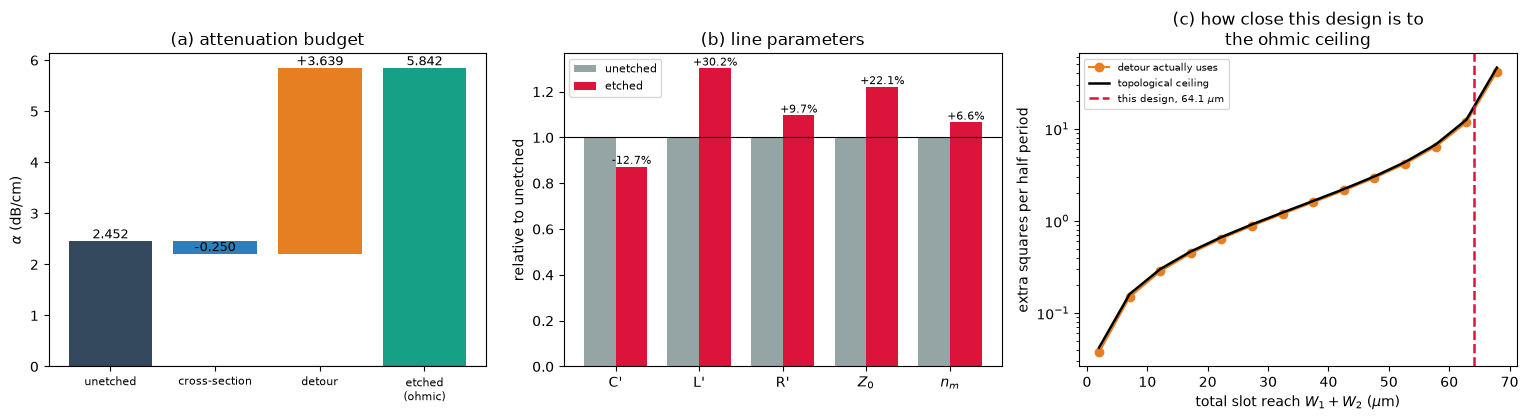

In [5]:
# %% [4] THE ANSWER for the geometry in cell [0]
A_SEC, A_DET = D["alpha"], DA_DETOUR
A_OHM = A_SEC + A_DET
LEAK_OPEN = N_BG > UNETCHED["n_m"]

print("=" * 96)
print(f"RESULT  --  {GEOM['name']},  tee W1={TEE['W1']:.3f} W2={TEE['W2']:.3f} "
      f"L1={TEE['L1']:.3f} L2={TEE['L2']:.3f} um, pitch {PITCH:.1f} um")
print("=" * 96)
print(f"{'':<26}{'unetched':>14}{'etched':>14}{'delta':>14}{'delta %':>12}")
print("-" * 96)
for lab, key, sc, unit in (("C'", "C", 1e12, "pF/m"), ("L'", "L", 1e9, "nH/m"),
                           ("R'", "Rp", 1e-3, "kOhm/m"), ("Z0", "Z0", 1.0, "ohm"),
                           ("n_m", "n_m", 1.0, "-")):
    u, e = UNETCHED[key] * sc, ETCHED[key] * sc
    print(f"  {lab+' ('+unit+')':<24}{u:>14.4f}{e:>14.4f}{e-u:>+14.4f}"
          f"{100*(e-u)/u:>+11.2f} %")
print("-" * 96)
print(f"  {'alpha (dB/cm)':<24}{UNETCHED['alpha']:>14.4f}"
      f"{UNETCHED['alpha']+A_OHM:>14.4f}{A_OHM:>+14.4f}"
      f"{100*A_OHM/UNETCHED['alpha']:>+11.2f} %")
print(f"      of which cross-section {A_SEC:>+14.4f}")
print(f"      of which detour        {A_DET:>+14.4f}")
print("=" * 96)
print("HOW TO USE THIS")
print("-" * 96)
print("  The perturbation is what you carry across to the 2D FEM baseline:")
print(f"      alpha_total = alpha_2D_FEM + ({A_OHM:+.4f}) dB/cm")
print(f"      n_m_total   = n_m_2D_FEM   + ({D['n_m']:+.5f})")
print(f"      Z0_total    = Z0_2D_FEM    + ({D['Z0']:+.4f}) ohm")
print("  It is additive by construction: set W1 = W2 = 0 in cell [0] and every")
print("  delta above collapses to zero identically, because the etched cell then")
print("  IS its own unetched reference on the same mesh.  So it cannot double")
print("  count anything the baseline already has.")
print(f"  The unetched column above ({UNETCHED['alpha']:.4f} dB/cm) is this notebook's")
print("  own baseline at its own mesh setting.  For a production number take the")
print("  baseline from RF_interface_optimized.ipynb, which resolves the electrode")
print("  corners far harder, and add the deltas from here.")
print("=" * 96)
print("WHAT IS NOT IN THIS NUMBER")
print("-" * 96)
if LEAK_OPEN:
    print(f"  The stack carries a background wave at n = {N_BG:.4f}, slower than this")
    print(f"  line's n_m = {UNETCHED['n_m']:.4f}, so power CAN leave the guide.  A slot cut")
    print( "  through the ground is an aperture into that channel, and a quasi-static")
    print( "  cell has no radiation channel of any kind -- so the delta alpha above is")
    print( "  the OHMIC part only, and it is a lower bound on the true penalty.")
    print(f"  Sanity gauge: the detour is using {DN:.1f} of the {N_CAP-N_FLAT:.1f} extra squares")
    print( "  the topology can supply.  The closer that ratio gets to 1, the more of")
    print( "  the real penalty has to be coming from somewhere other than gold.")
    print(f"     -> using {100*DN/max(N_CAP-N_FLAT,1e-9):.0f} % of the ohmic ceiling.")
else:
    print( "  No background wave of this stack is slower than the mode, so nothing")
    print( "  can carry power away laterally: there is no radiative channel to miss.")
    print( "  The delta alpha above is the whole perturbation, to quasi-static order.")
print("=" * 96)

# ---- figure ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.3))

ax = axes[0]
steps = ["unetched", "cross-section", "detour", "etched\n(ohmic)"]
base = UNETCHED["alpha"]
lefts = [0.0, base, base + A_SEC, 0.0]
hts = [base, A_SEC, A_DET, base + A_OHM]
cols = ["#34495e", "#2c7fb8", "#e67e22", "#16a085"]
for i, (l, hgt, c) in enumerate(zip(lefts, hts, cols)):
    ax.bar(i, hgt, bottom=l, color=c)
    ax.text(i, l + hgt, f"{hgt:+.3f}" if 0 < i < 3 else f"{hgt:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(4)); ax.set_xticklabels(steps, fontsize=8)
ax.set_ylabel(r"$\alpha$ (dB/cm)"); ax.axhline(0, color="k", lw=0.8)
ax.set_title("(a) attenuation budget")

ax = axes[1]
keys = [("C'", "C"), ("L'", "L"), ("R'", "Rp"), (r"$Z_0$", "Z0"), (r"$n_m$", "n_m")]
xx = np.arange(len(keys)); w = 0.38
ax.bar(xx - w / 2, [1.0] * len(keys), w, color="#95a5a6", label="unetched")
ax.bar(xx + w / 2, [ETCHED[k] / UNETCHED[k] for _, k in keys], w,
       color="crimson", label="etched")
for i, (_, k) in enumerate(keys):
    ax.text(i + w / 2, ETCHED[k] / UNETCHED[k],
            f"{100*(ETCHED[k]/UNETCHED[k]-1):+.1f}%", ha="center",
            va="bottom", fontsize=8)
ax.axhline(1.0, color="k", lw=0.8)
ax.set_xticks(xx); ax.set_xticklabels([n for n, _ in keys])
ax.set_ylabel("relative to unetched"); ax.legend(fontsize=8)
ax.set_title("(b) line parameters")

ax = axes[2]
ws = np.linspace(2.0, 0.97 * (X_GO - X_GI), 14)
frac = TEE["W1"] / max(TEE["W1"] + TEE["W2"], 1e-9)
sq, capq = [], []
for wtot in ws:
    t = dict(TEE); t["W1"], t["W2"] = frac * wtot, (1 - frac) * wtot
    sq.append(detour(t, h=1.0) - N_FLAT)
    capq.append((PITCH / 2.0) / max(W_DEV - S_OF_X(min(X_GI + wtot, X_GO)), 1e-9) - N_FLAT)
ax.plot(ws, sq, "o-", color="#e67e22", label="detour actually uses")
ax.plot(ws, capq, "k-", lw=1.8, label="topological ceiling")
ax.axvline(TEE["W1"] + TEE["W2"], color="crimson", lw=1.8, ls="--",
           label=f"this design, {TEE['W1']+TEE['W2']:.1f} $\\mu$m")
ax.set_yscale("log"); ax.set_xlabel(r"total slot reach $W_1+W_2$ ($\mu$m)")
ax.set_ylabel("extra squares per half period")
ax.legend(fontsize=7.5)
ax.set_title("(c) how close this design is to\nthe ohmic ceiling")
plt.tight_layout(); plt.show()


RECORDED CST MULTILAYER SWEEP  (498 geometries, /home/user/claude/notebooks/data/cst_multilayer_500.csv)
------------------------------------------------------------------------------------------------
  unetched: the multilayer N+1-N differential sits BELOW the COMSOL 2D
  FEM by 7.04 +/- 1.71 %, on all 498 rows, and the shortfall
  tracks GAP (-0.41) and MTX (+0.30) -- the parameters that set how sharp
  the electrode corner is.  An extra loss channel would push it UP; an
  under-resolved edge singularity pushes it down.  So on a UNIFORM line
  leakage is below the meshing residual, which is why the 2D FEM baseline
  is free to be a purely ohmic + dielectric calculation.
------------------------------------------------------------------------------------------------
  etched: recorded delta spans -1.072 to +17.221 dB/cm (27 % relief)
  the geometry in cell [0] IS row 277 of that sweep:
     recorded  delta_ML = +17.2209 dB/cm
     this code delta_ohmic = +3.3897 dB/cm   (20 % of it)


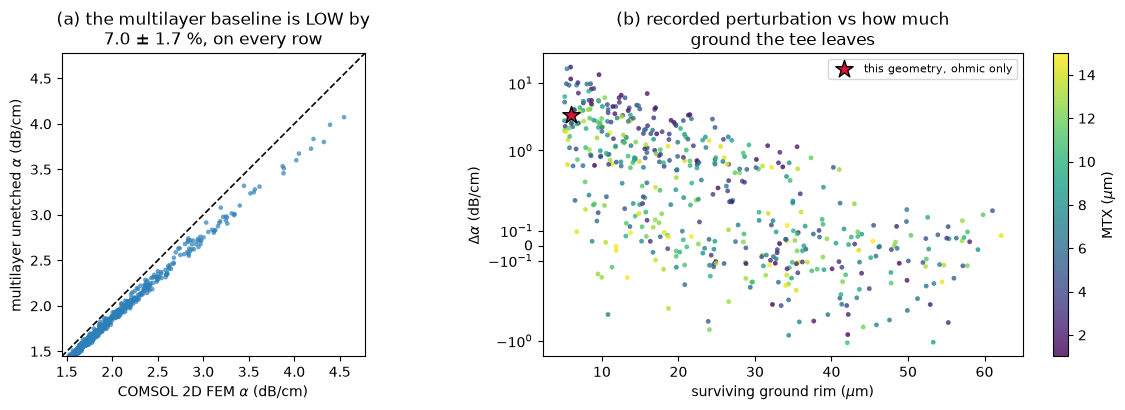

In [6]:
# %% [5] Optional context -- the recorded CST multilayer sweep, if it is there
#
# Nothing above needed this.  It is here so the ohmic number just computed can
# be put next to the 500-geometry multilayer reference, which is the only way to
# see how much of the real perturbation the ohmic channel covers.  If the file
# is not next to the notebook this cell prints one line and stops.
def _find(name, where="data"):
    here = pathlib.Path.cwd().resolve()
    for b in [here, *here.parents]:
        for c in (b / where / name, b / "notebooks" / where / name):
            if c.is_file():
                return c
    return None


_ref = _find("cst_multilayer_500.csv")
if _ref is None:
    print("data/cst_multilayer_500.csv not found -- skipping the comparison.")
    print("Everything in cells [0]-[4] stands without it.")
else:
    import pandas as pd
    REF = pd.read_csv(_ref)
    rim = (70.0 - REF.W1 - REF.W2).values
    print("=" * 96)
    print(f"RECORDED CST MULTILAYER SWEEP  ({len(REF)} geometries, {_ref})")
    print("-" * 96)
    gapp = 100 * REF.baseline_gap / REF.alpha_COMSOL
    print(f"  unetched: the multilayer N+1-N differential sits BELOW the COMSOL 2D")
    print(f"  FEM by {gapp.mean():.2f} +/- {gapp.std():.2f} %, on all {len(REF)} rows, and the shortfall")
    print(f"  tracks GAP ({np.corrcoef(gapp, REF.GAP)[0,1]:+.2f}) and MTX "
          f"({np.corrcoef(gapp, REF.MTX)[0,1]:+.2f}) -- the parameters that set how sharp")
    print( "  the electrode corner is.  An extra loss channel would push it UP; an")
    print( "  under-resolved edge singularity pushes it down.  So on a UNIFORM line")
    print( "  leakage is below the meshing residual, which is why the 2D FEM baseline")
    print( "  is free to be a purely ohmic + dielectric calculation.")
    print("-" * 96)
    print(f"  etched: recorded delta spans {REF.delta_ML.min():+.3f} to "
          f"{REF.delta_ML.max():+.3f} dB/cm ({(REF.delta_ML<0).mean()*100:.0f} % relief)")
    tol = 1e-3
    hit = REF[(np.abs(REF.W1 - TEE["W1"]) < tol) & (np.abs(REF.W2 - TEE["W2"]) < tol) &
              (np.abs(REF.L1 - TEE["L1"]) < tol) & (np.abs(REF.L2 - TEE["L2"]) < tol)]
    if len(hit):
        r = hit.iloc[0]
        print(f"  the geometry in cell [0] IS row {int(r.Index)} of that sweep:")
        print(f"     recorded  delta_ML = {r.delta_ML:+.4f} dB/cm")
        print(f"     this code delta_ohmic = {A_OHM:+.4f} dB/cm"
              f"   ({100*A_OHM/r.delta_ML:.0f} % of it)")
        print(f"     unaccounted            {r.delta_ML - A_OHM:+.4f} dB/cm  <- the leakage channel")
    print("=" * 96)

    fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2))
    ax = axes[0]
    ax.scatter(REF.alpha_COMSOL, REF.alpha_ML_unetched, s=11, c="#2c7fb8",
               alpha=0.7, edgecolors="none")
    lim = [REF.alpha_COMSOL.min() * 0.95, REF.alpha_COMSOL.max() * 1.05]
    ax.plot(lim, lim, "k--", lw=1.2)
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
    ax.set_xlabel(r"COMSOL 2D FEM $\alpha$ (dB/cm)")
    ax.set_ylabel(r"multilayer unetched $\alpha$ (dB/cm)")
    ax.set_title(f"(a) the multilayer baseline is LOW by\n"
                 f"{gapp.mean():.1f} $\\pm$ {gapp.std():.1f} %, on every row")

    ax = axes[1]
    ax.scatter(rim, REF.delta_ML, s=12, c=REF.MTX, cmap="viridis",
               alpha=0.8, edgecolors="none")
    ax.scatter([W_DEV - TEE["W1"] - TEE["W2"]], [A_OHM], s=170, marker="*",
               c="crimson", edgecolors="k", zorder=5,
               label="this geometry, ohmic only")
    ax.set_yscale("symlog", linthresh=0.5)
    ax.set_xlabel(r"surviving ground rim ($\mu$m)")
    ax.set_ylabel(r"$\Delta\alpha$ (dB/cm)")
    ax.legend(fontsize=8)
    ax.set_title("(b) recorded perturbation vs how much\nground the tee leaves")
    plt.colorbar(ax.collections[0], ax=ax, label=r"MTX ($\mu$m)")
    plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# To sweep a parameter, loop cells [2]-[3].  Cost is about 12 s per cross-section,
# so four sections per point:
#
#   out = []
#   for w1 in [10.0, 20.0, 30.0, 40.0]:
#       TEE = dict(TEE, W1=w1); SECTIONS = tee_sections()
#       <re-run cell [2] and cell [3]>
#       out.append((w1, D["C"], D["L"], D["alpha"] + DA_DETOUR))
# ---------------------------------------------------------------------------
